# Walking-Network Accessibility to Public Transport Stops (Munich, OpenStreetMap)

This notebook estimates walking-network accessibility to public transport stops in Munich using OpenStreetMap data. The workflow uses **OSMnx** to download and project the pedestrian network, **GeoPandas** for spatial processing, and **NetworkX** to compute shortest walking distances along the network.

**Scope and limitations**
- Measures *walking-network distance* to the nearest stop feature extracted from OSM tags.
- Does not model public-transport travel time, schedules, frequency, or transfers.
- Results depend on OpenStreetMap coverage and tagging consistency for stop features.

# Table of contents

- [1 - Imports & libraries](#imports-libraries)
- [2 - Project settings & configuration](#project-settings)
- [3 - Download walking network (OSM)](#download-walking-network)
- [4 - Network statistics](#network-statistics)
- [5 - Convert graph to GeoDataFrames (nodes & edges)](#convert-graph-to-geodataframes)
- [6 - Visualize walking network](#visualize-walking-network)
- [7 - Initial extraction summary](#initial-network-extraction-result)
- [8 - Extract public transport stops from OSM](#extract-public-transport-stops-from-osm)
- [9 - Clean transit-stop geometries](#clean-transit-stop-geometries)
- [10 - Link transit stops to the walking network](#link-stops-to-network)
- [11 - Compute network-based accessibility](#compute-accessibility)
- [12 - Accessibility bands](#accessibility-bands)
- [13 - Visualizations](#visualizations)
  - [13.1 Node-level accessibility map](#node-level-accessibility-map)
  - [13.2 Optional: walking-time estimate](#walking-time)
  - [13.3 Edge-level accessibility map](#edge-level-accessibility-map)
  - [13.4 Distance distribution histogram](#distance-distribution)

<a id="imports-libraries"></a>
## 1 - Imports & libraries

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

<a id="project-settings"></a>
## 2 - Project settings & configuration

In [3]:
# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = True

PLACE_NAME = "Munich, Bavaria, Germany"

PLACE_NAME

'Munich, Bavaria, Germany'

<a id="download-walking-network"></a>
## 3 - Download walking network (OSM)

In [4]:
# Download the walking street network for Munich from OpenStreetMap
G = ox.graph_from_place(
    PLACE_NAME,
    network_type="walk",
    simplify=True
)

# Project graph to a local metric coordinate system for distance calculations
G_proj = ox.project_graph(G)

G_proj

<a id="network-statistics"></a>
## 4 - Network statistics

In [6]:
# Basic network statistics
stats = ox.basic_stats(G_proj)

# Get Munich boundary polygon to calculate area
munich_boundary = ox.geocode_to_gdf(PLACE_NAME)
munich_boundary_proj = munich_boundary.to_crs(edges.crs if "edges" in globals() else ox.graph_to_gdfs(G_proj, nodes=False).crs)

area_m2 = munich_boundary_proj.geometry.area.iloc[0]
area_km2 = area_m2 / 1_000_000

selected_stats = {
    "Number of nodes": stats.get("n"),
    "Number of edges": stats.get("m"),
    "Total edge length (km)": stats.get("edge_length_total", 0) / 1000,
    "Average edge length (m)": stats.get("edge_length_avg"),
    "Intersection count": stats.get("intersection_count"),
    "Munich boundary area (km²)": area_km2,
    "Street density (km/km²)": (stats.get("edge_length_total", 0) / 1000) / area_km2,
    "Intersection density (count/km²)": stats.get("intersection_count", 0) / area_km2,
}

pd.Series(selected_stats)

Number of nodes                     148230.000000
Number of edges                     387928.000000
Total edge length (km)               15281.244298
Average edge length (m)                 39.391960
Intersection count                  105985.000000
Munich boundary area (km²)             310.737328
Street density (km/km²)                 49.177369
Intersection density (count/km²)       341.075856
dtype: float64

<a id="convert-graph-to-geodataframes"></a>
## 5 - Convert graph to GeoDataFrames (nodes & edges)

In [10]:
# Convert graph to GeoDataFrames for nodes and edges
nodes, edges = ox.graph_to_gdfs(G_proj)

print(f"Nodes: {len(nodes):,}")
print(f"Edges: {len(edges):,}")

nodes.head()


Nodes: 148,230
Edges: 387,928


,y,x,street_count,highway,railway,ref,geometry
osmid,,,,,,,
128236,5.339065e+06,678051.022963,1,NaN,NaN,NaN,POINT (678051.023 5339064.73)
1399723741,5.339058e+06,678048.766587,4,NaN,NaN,NaN,POINT (678048.767 5339057.874)
128239,5.338986e+06,678321.975388,1,NaN,NaN,NaN,POINT (678321.975 5338985.899)
9497553538,5.338987e+06,678326.056827,3,NaN,NaN,NaN,POINT (678326.057 5338987.194)
128258,5.337587e+06,679336.821688,1,NaN,NaN,NaN,POINT (679336.822 5337586.869)


In [11]:
# Check the coordinate reference system and geometry types
print("Nodes CRS:", nodes.crs)
print("Edges CRS:", edges.crs)

print("\nNode geometry types:")
print(nodes.geometry.geom_type.value_counts())

print("\nEdge geometry types:")
print(edges.geometry.geom_type.value_counts())

Nodes CRS: EPSG:32632
Edges CRS: EPSG:32632

Node geometry types:
Point    148230
Name: count, dtype: int64

Edge geometry types:
LineString    387928
Name: count, dtype: int64


<a id="visualize-walking-network"></a>
## 6 - Visualize walking network

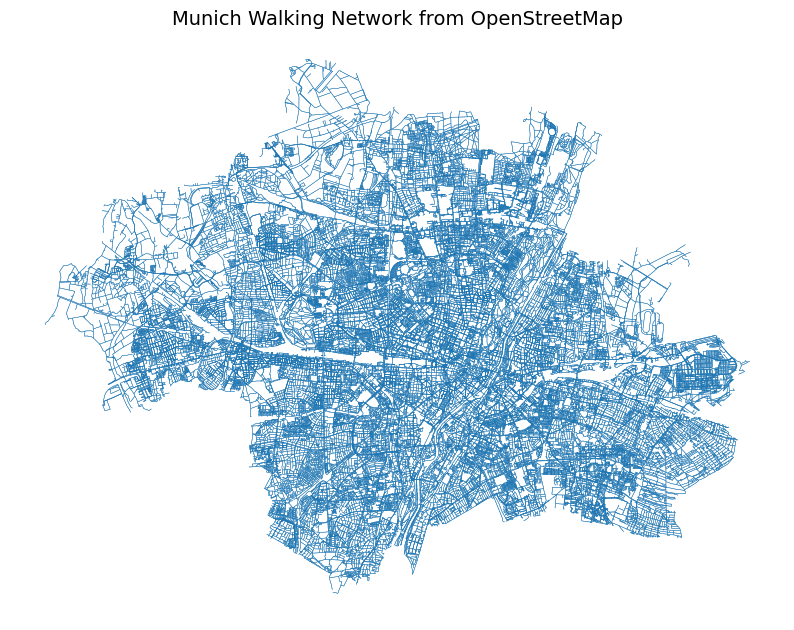

WindowsPath('d:/repos/Munich/osm-network-accessibility-munich/outputs/munich_walking_network.png')

In [13]:
# Visualize the walking network
fig, ax = plt.subplots(figsize=(10, 10))

edges.plot(ax=ax, linewidth=0.3)
ax.set_title("Munich Walking Network from OpenStreetMap", fontsize=14)
ax.axis("off")

output_path = OUTPUT_DIR / "munich_walking_network.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

<a id="initial-network-extraction-result"></a>
## 7 - Initial extraction summary

This section summarizes the output of the walking-network extraction and projection step. In this run, the Munich walking network contains **148,230 nodes** and **387,928 edges**. After projection to **EPSG:32632**, edge lengths are in meters, which supports distance-based accessibility calculations.

The node layer consists of point geometries and the edge layer consists of line geometries, confirming that the OpenStreetMap network was successfully converted into spatial layers for analysis and visualization.

<a id="extract-public-transport-stops-from-osm"></a>
## 8 - Extract public transport stops from OSM

### 8.1 - Define OSM tags for transit stops

This step extracts stop locations from OpenStreetMap using a small set of commonly mapped tags (e.g., bus stops, stations, platforms, stop positions). These features are later linked to the walking network and used as source points for shortest-path distance calculations.

In [23]:
# OSM tags used to extract public transport-related features
transit_tags = {
    "highway": "bus_stop",
    "railway": ["station", "halt", "tram_stop"],
    "public_transport": ["platform", "stop_position", "station"]
}

transit_tags

{'highway': 'bus_stop',
 'railway': ['station', 'halt', 'tram_stop'],
 'public_transport': ['platform', 'stop_position', 'station']}

### 8.2 - Download transit features

In [24]:
# Download public transport-related features from OpenStreetMap
transit_features = ox.features_from_place(
    PLACE_NAME,
    tags=transit_tags
)

print(f"Raw transit features: {len(transit_features):,}")
transit_features.head()

Raw transit features: 6,426


geometry  bus                   name network  \
element id                                                                      
node    245347  POINT (11.52027 48.14627)  yes    Wilhelm-Hale-Straße     NaN   
        295383  POINT (11.46862 48.17742)  yes      Willi-Wien-Straße     NaN   
        398761  POINT (11.58782 48.13766)  NaN            Maxmonument     MVV   
        428662   POINT (11.71534 48.1364)  yes  Sigmund-Riefler-Bogen     NaN   
        444575  POINT (11.50773 48.15276)  yes      Hirschgartenallee     NaN   

               operator public_transport share_taxi  \
element id                                            
node    245347      NaN    stop_position        NaN   
        295383      NaN    stop_position        NaN   
        398761      MVG    stop_position        NaN   
        428662      NaN    stop_position        NaN   
        444575      NaN    stop_position        NaN   

                                                  description railway tram  \
element id                                                                   
node    245347                                            NaN     NaN  NaN   
        295383                                            NaN     NaN  NaN   
        398761  Maxmonument, Stop Tram 19/N19 Richtung Pasing    stop  yes   
        428662                                            NaN     NaN  NaN   
        444575                                            NaN     NaN  NaN   

                ... check_date:lit seats backrest disused:public_transport  \
element id      ...                                                          
node    245347  ...            NaN   NaN      NaN                      NaN   
        295383  ...            NaN   NaN      NaN                      NaN   
        398761  ...            NaN   NaN      NaN                      NaN   
        428662  ...            NaN   NaN      NaN                      NaN   
        444575  ...            NaN   NaN      NaN                      NaN   

               contact:website end_date noexit type multipolygon source:height  
element id                                                                      
node    245347             NaN      NaN    NaN  NaN          NaN           NaN  
        295383             NaN      NaN    NaN  NaN          NaN           NaN  
        398761             NaN      NaN    NaN  NaN          NaN           NaN  
        428662             NaN      NaN    NaN  NaN          NaN           NaN  
        444575             NaN      NaN    NaN  NaN          NaN           NaN  

[5 rows x 169 columns]

### 8.3 - Inspect geometry types

In [25]:
# Inspect geometry types before cleaning
transit_features.geometry.geom_type.value_counts()

Point         3753
Polygon       2605
LineString      68
Name: count, dtype: int64

<a id="clean-transit-stop-geometries"></a>
## 9 - Clean transit-stop geometries

The raw transit layer can include **points, lines, and polygons**. For a nearest-stop accessibility calculation, each feature needs a single point location.

- Point geometries are kept as-is.
- Line and polygon geometries are converted to a representative point.
- The cleaned stop points are projected to the same CRS as the walking network.

### 9.1 - Convert all transit features to points

In [26]:
# Convert all transit geometries to point locations
transit_points = transit_features.copy()

# Convert geometries to representative points.
# For existing points, the geometry stays effectively unchanged.
# For polygons and lines, representative_point() returns a point located on or near the feature.
transit_points["geometry"] = transit_points.geometry.representative_point()

# Project transit points to the same CRS as the walking network
transit_points = transit_points.set_crs(transit_features.crs)
transit_points = transit_points.to_crs(nodes.crs)

print(f"Transit point features after geometry conversion: {len(transit_points):,}")
print("CRS:", transit_points.crs)
print(transit_points.geometry.geom_type.value_counts())

Transit point features after geometry conversion: 6,426
CRS: EPSG:32632
Point    6426
Name: count, dtype: int64


### 9.2 - Keep useful columns

In [27]:
# Keep only columns useful for inspection and mapping
useful_columns = [
    "name",
    "public_transport",
    "highway",
    "railway",
    "bus",
    "tram",
    "train",
    "subway",
    "operator",
    "network",
    "geometry"
]

available_columns = [col for col in useful_columns if col in transit_points.columns]

transit_points_clean = transit_points[available_columns].copy()

transit_points_clean.head()

name public_transport highway railway  bus  \
element id                                                                    
node    245347    Wilhelm-Hale-Straße    stop_position     NaN     NaN  yes   
        295383      Willi-Wien-Straße    stop_position     NaN     NaN  yes   
        398761            Maxmonument    stop_position     NaN    stop  NaN   
        428662  Sigmund-Riefler-Bogen    stop_position     NaN     NaN  yes   
        444575      Hirschgartenallee    stop_position     NaN     NaN  yes   

               tram train subway operator network  \
element id                                          
node    245347  NaN   NaN    NaN      NaN     NaN   
        295383  NaN   NaN    NaN      NaN     NaN   
        398761  yes   NaN    NaN      MVG     MVV   
        428662  NaN   NaN    NaN      NaN     NaN   
        444575  NaN   NaN    NaN      NaN     NaN   

                                      geometry  
element id                                      
node    245347  POINT (687462.268 5335630.028)  
        295383  POINT (683509.643 5338967.419)  
        398761   POINT (692518.78 5334839.866)  
        428662  POINT (702009.446 5335026.617)  
        444575   POINT (686505.86 5336320.155)

### 9.3 - Remove exact duplicate geometries

In [28]:
# Remove exact duplicate point geometries
before = len(transit_points_clean)

transit_points_clean["geometry_wkt"] = transit_points_clean.geometry.to_wkt()
transit_points_clean = transit_points_clean.drop_duplicates(subset="geometry_wkt")
transit_points_clean = transit_points_clean.drop(columns="geometry_wkt")

after = len(transit_points_clean)

print(f"Features before duplicate removal: {before:,}")
print(f"Features after duplicate removal: {after:,}")
print(f"Removed duplicates: {before - after:,}")

Features before duplicate removal: 6,426
Features after duplicate removal: 6,420
Removed duplicates: 6


### 9.4 - Plot transit points over the walking network

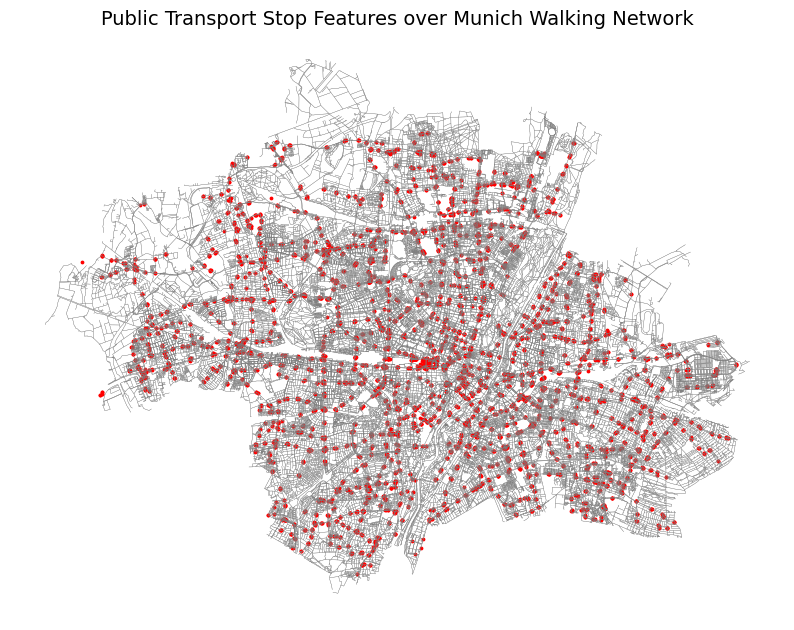

WindowsPath('d:/repos/Munich/osm-network-accessibility-munich/outputs/munich_transit_stops_on_network.png')

In [30]:
fig, ax = plt.subplots(figsize=(10, 10))

# Change 'gray' to any color you prefer for the network lines
edges.plot(ax=ax, linewidth=0.2, color="gray")

# Change 'red' to any color you prefer for the transit stops
transit_points_clean.plot(ax=ax, markersize=3, color="red")

ax.set_title("Public Transport Stop Features over Munich Walking Network", fontsize=14)
ax.axis("off")

output_path = OUTPUT_DIR / "munich_transit_stops_on_network.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

<a id="link-stops-to-network"></a>
## 10 - Link transit stops to the walking network

Transit stops are stored as point geometries, while the walking network is stored as a graph (nodes and edges). To compute network-based accessibility, each stop is linked to its **nearest network node**. These linked nodes become the source set for the shortest-path calculations.

In [31]:
# Create an undirected version of the walking graph for accessibility analysis
G_access = ox.convert.to_undirected(G_proj)

# Make a copy so we can safely add new columns
transit_points_clean = transit_points_clean.copy()

# Find the nearest network node for each transit stop point
transit_points_clean["nearest_node"] = ox.distance.nearest_nodes(
    G_access,
    X=transit_points_clean.geometry.x,
    Y=transit_points_clean.geometry.y
)

# Keep only the unique source nodes
source_nodes = transit_points_clean["nearest_node"].unique().tolist()

print(f"Transit stop features: {len(transit_points_clean):,}")
print(f"Unique nearest network nodes used as transit-stop sources: {len(source_nodes):,}")

transit_points_clean[["name", "public_transport", "nearest_node"]].head()

Transit stop features: 6,420
Unique nearest network nodes used as transit-stop sources: 4,195


name public_transport  nearest_node
element id                                                          
node    245347    Wilhelm-Hale-Straße    stop_position    4724788653
        295383      Willi-Wien-Straße    stop_position    1568267200
        398761            Maxmonument    stop_position    3194123464
        428662  Sigmund-Riefler-Bogen    stop_position    8555080483
        444575      Hirschgartenallee    stop_position    3945592886

<a id="compute-accessibility"></a>
## 11 - Compute network-based accessibility

This step calculates the shortest walking distance from every network node to the nearest stop-linked source node using a **multi-source Dijkstra** algorithm. Edge length is used as the distance weight.

In [32]:
# Compute shortest walking distance from every network node
# to the nearest transit-stop source node
distance_to_nearest_stop = nx.multi_source_dijkstra_path_length(
    G_access,
    source_nodes,
    weight="length"
)

# Attach the result to the nodes GeoDataFrame
nodes_access = nodes.copy()
nodes_access["distance_to_nearest_stop_m"] = nodes_access.index.map(distance_to_nearest_stop)

# Basic summary
nodes_access["distance_to_nearest_stop_m"].describe()

count    148230.000000
mean        247.168597
std         226.187520
min           0.000000
25%         108.720877
50%         207.981978
75%         327.261012
max        4667.180772
Name: distance_to_nearest_stop_m, dtype: float64

In this run, the multi-source shortest-path calculation assigns a nearest-stop walking distance to all network nodes. The distribution is typically right-skewed: most nodes are close to a stop, while a smaller number of peripheral or weakly connected areas have much larger distances.

<a id="accessibility-bands"></a>
## 12 - Accessibility bands

To make the results easier to interpret, raw distance values are grouped into four categories: **0–250 m**, **250–500 m**, **500–750 m**, and **750+ m**.

In [33]:
# Create accessibility bands
bins = [0, 250, 500, 750, float("inf")]
labels = ["0–250 m", "250–500 m", "500–750 m", "750+ m"]

nodes_access["accessibility_band"] = pd.cut(
    nodes_access["distance_to_nearest_stop_m"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

band_summary = nodes_access["accessibility_band"].value_counts().sort_index()
band_share = (band_summary / len(nodes_access) * 100).round(1)

pd.DataFrame({
    "count": band_summary,
    "share_percent": band_share
})

,count,share_percent
accessibility_band,,
0–250 m,88656,59.8
250–500 m,47184,31.8
500–750 m,8717,5.9
750+ m,3673,2.5


The band summary indicates that the large majority of walking-network nodes are within 500 meters of an extracted public transport stop in this run. Interpretation should account for the underlying OSM tagging completeness and the fact that this is **access distance** (not service quality or travel time).

<a id="visualizations"></a>
## 13 - Visualizations

<a id="node-level-accessibility-map"></a>
### 13.1 - Node-level accessibility map

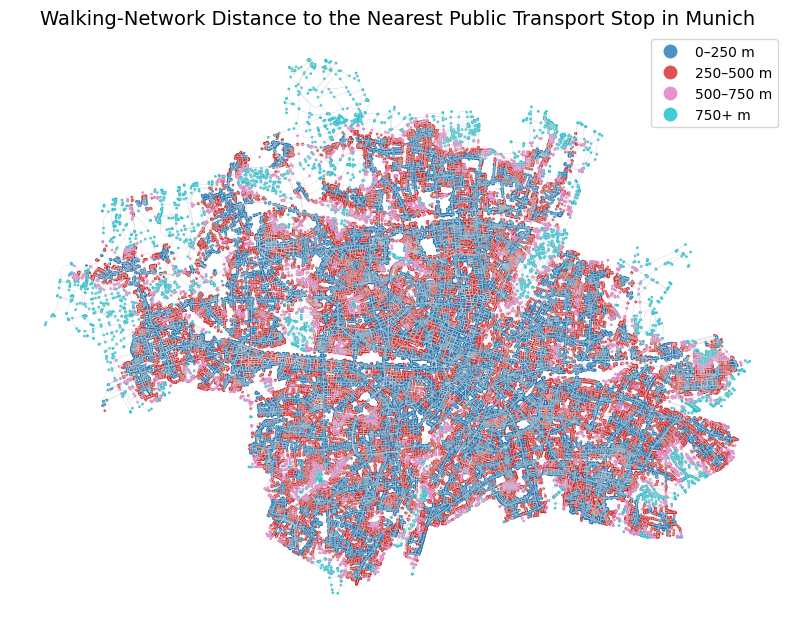

WindowsPath('d:/repos/Munich/osm-network-accessibility-munich/outputs/munich_accessibility_bands.png')

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the network lightly in the background
edges.plot(ax=ax, linewidth=0.15, color="lightgray")

# Plot nodes colored by accessibility band
nodes_access.plot(
    ax=ax,
    column="accessibility_band",
    categorical=True,
    legend=True,
    markersize=1,
    alpha=0.8
)

ax.set_title("Walking-Network Distance to the Nearest Public Transport Stop in Munich", fontsize=14)
ax.axis("off")

output_path = OUTPUT_DIR / "munich_accessibility_bands.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

Because the Munich walking network contains many nodes, plotting every node can produce visual clutter at city scale. The edge-level visualization below provides a cleaner communication graphic, while preserving the same underlying accessibility calculation.

<a id="walking-time"></a>
### 13.2 - Optional: walking-time estimate

In [35]:
# Optional: convert distance to approximate walking time
# Assumption: average walking speed = 5 km/h = 83.33 meters per minute
nodes_access["walking_time_to_nearest_stop_min"] = nodes_access["distance_to_nearest_stop_m"] / 83.33

nodes_access["walking_time_to_nearest_stop_min"].describe()

count    148230.000000
mean          2.966142
std           2.714359
min           0.000000
25%           1.304703
50%           2.495884
75%           3.927289
max          56.008410
Name: walking_time_to_nearest_stop_min, dtype: float64

Using an assumed average walking speed of **5 km/h** (≈ 83.33 m/min), the network distance can be expressed as an approximate walking time. This is a simple conversion and does not account for slope, crossings, signal delays, or other local conditions.

<a id="edge-level-accessibility-map"></a>
### 13.3 - Edge-level accessibility map

For a cleaner map, each edge is assigned the accessibility band of its start node ("u"). This approximation improves readability while still reflecting the spatial pattern of access distances across the network.

In [36]:
# Prepare node accessibility values for merging with edges
node_access_for_edges = nodes_access[["distance_to_nearest_stop_m", "accessibility_band"]].copy()
node_access_for_edges.index.name = "u"

# Reset edge index so that each edge has its start node u and end node v as columns
edges_access = edges.reset_index().merge(
    node_access_for_edges,
    left_on="u",
    right_index=True,
    how="left"
)

edges_access = gpd.GeoDataFrame(edges_access, geometry="geometry", crs=edges.crs)

edges_access[["u", "v", "distance_to_nearest_stop_m", "accessibility_band", "geometry"]].head()

,u,v,distance_to_nearest_stop_m,accessibility_band,geometry
0,128236,1399723741,38.250929,0–250 m,"LINESTRING (678051.023 5339064.73, 678048.767 ..."
1,1399723741,128236,31.035171,0–250 m,"LINESTRING (678048.767 5339057.874, 678051.023..."
2,1399723741,9505497637,31.035171,0–250 m,"LINESTRING (678048.767 5339057.874, 678056.297..."
3,1399723741,10087857483,31.035171,0–250 m,"LINESTRING (678048.767 5339057.874, 678046.415..."
4,1399723741,4009244680,31.035171,0–250 m,"LINESTRING (678048.767 5339057.874, 677995.185..."


The plot below colors network edges by accessibility band, producing a less cluttered visualization than the node-level map.

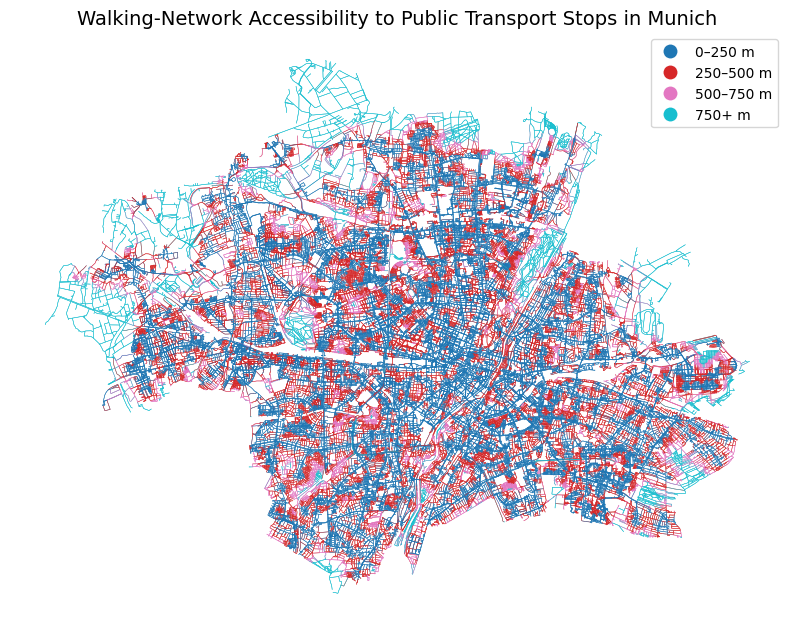

WindowsPath('d:/repos/Munich/osm-network-accessibility-munich/outputs/munich_edge_accessibility_bands.png')

In [37]:
fig, ax = plt.subplots(figsize=(10, 10))

edges_access.plot(
    ax=ax,
    column="accessibility_band",
    categorical=True,
    legend=True,
    linewidth=0.35
)

ax.set_title("Walking-Network Accessibility to Public Transport Stops in Munich", fontsize=14)
ax.axis("off")

output_path = OUTPUT_DIR / "munich_edge_accessibility_bands.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

<a id="distance-distribution"></a>
### 13.4 - Distance distribution histogram

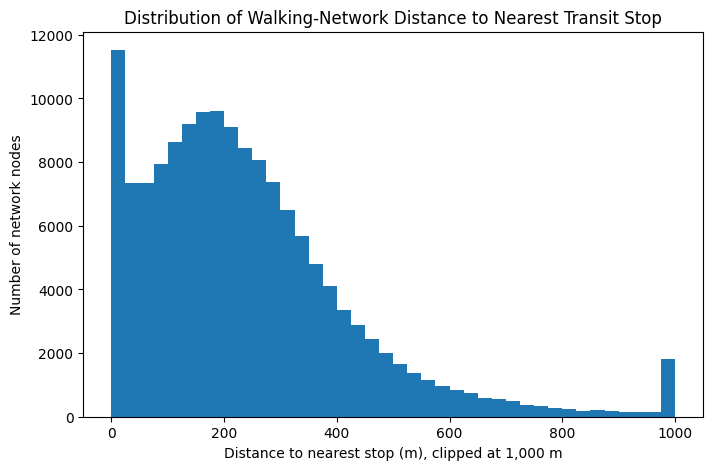

WindowsPath('d:/repos/Munich/osm-network-accessibility-munich/outputs/distance_distribution_histogram.png')

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

nodes_access["distance_to_nearest_stop_m"].clip(upper=1000).plot(
    kind="hist",
    bins=40,
    ax=ax
)

ax.set_title("Distribution of Walking-Network Distance to Nearest Transit Stop")
ax.set_xlabel("Distance to nearest stop (m), clipped at 1,000 m")
ax.set_ylabel("Number of network nodes")

output_path = OUTPUT_DIR / "distance_distribution_histogram.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

## Key findings and limitations

This analysis suggests that a large share of Munich’s walking network has relatively short walking distances to extracted public transport stop features. Based on the network-node results, 59.8% of nodes are within 250 meters of the nearest stop and 91.6% are within 500 meters.

However, the analysis has several limitations. First, the stop layer is derived from OpenStreetMap tags and may contain inconsistencies, omissions, or duplicate representations of the same stop infrastructure. Second, the analysis measures walking-network distance to the nearest extracted stop feature, not full public-transport accessibility or door-to-door travel time. Third, no demographic or socio-economic data is included, so the project does not directly measure inequality in access.